This notebook is to understand the high chirp mass, low spin population.

These seems to be massive stars that do not have a long interaction during the STAR+STAR phase
and then do not interact during the STAR+BH phase. Thus, both stellar components are only minimally spinning.


In [1]:
import h5py
import numpy as np
import matplotlib.pyplot as plt
import os
from pathlib import Path
from cmap import Colormap
from scipy.stats import gaussian_kde

from posydon.config import PATH_TO_POSYDON
from posydon.popsyn.synthetic_population import Rates
from posydon.popsyn.rate_calculation import get_shell_comoving_volume

Processing folder: Eddington-limited
Missing ini parameter: orbital_separation_scheme
Missing ini parameter: orbital_separation_min
Missing ini parameter: orbital_separation_max
Rates data loaded.
metallicity
0.0001    1955
0.0010    1611
0.0100     557
0.1000       1
Name: count, dtype: int64


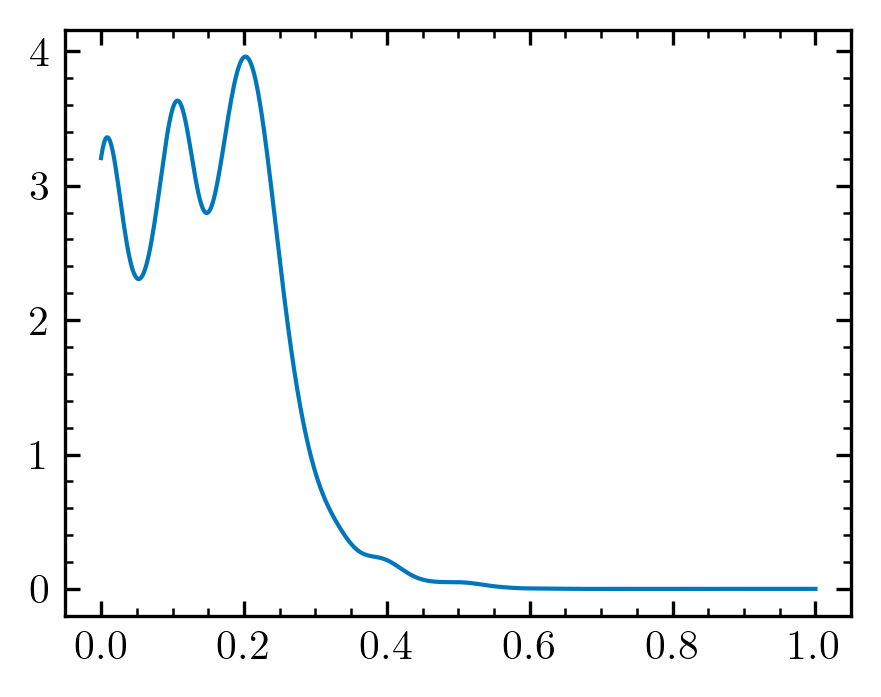

In [2]:

plt.style.use(str(Path(PATH_TO_POSYDON) / 'posydon' / 'visualization' / 'posydon.mplstyle'))


# Define the data directory and folder types
data_dir = '/home/users/b/briel/scratch/high_mass_physics/data/main_figure/'
folder_types = ['Eddington-limited', 'GRMHD', 'conservative']
SFH_type = 'IllustrisTNG'

title_mapping = {
    'no_kick': '',
    'low_kick': '-Low',
    'normal_kick': '-Normal',
}

cm = Colormap('tol:vibrant')

colours = cm([0.1, 0.2, 0.3, 0.5, 0.6, 0.8])

chi_eff_bins = np.linspace(0, 1, 51)

for i, folder_type in enumerate(folder_types[:-2]):
    print(f"Processing folder: {folder_type}")
    co_contact_file = os.path.join(data_dir, folder_type+'.h5',)
    #co_contact_file = os.path.join(folder_path, 'CO_contact.h5')
    data = Rates(co_contact_file, 'BBH', SFH_type)
    print("Rates data loaded.")
    max_mass = np.maximum(data.population['S1_mass'].values, data.population['S2_mass'].values)
    mask = max_mass > 40
    z_max = 2
    z_event_mask = data.z_events <= z_max
    volume = get_shell_comoving_volume(0, z_max)
    weights = data.weights[z_event_mask][mask]
    filtered_population = data.population[mask]
    chirp_mass = filtered_population['chirp_mass'].to_numpy()
    mass_ratio = filtered_population['mass_ratio'].to_numpy()
    chi_eff = np.where(filtered_population['S1_mass'] >= filtered_population['S2_mass'], filtered_population['S1_spin'].to_numpy(), filtered_population['S2_spin'].to_numpy())
    print(filtered_population['metallicity'].value_counts())
    # plot KDE
    kde = gaussian_kde(chi_eff, weights=np.nansum(weights, axis=1)/volume)
    x_eval = np.linspace(0, 1.0, 500)
    kde_values = kde(x_eval)
    if folder_type in tuple(title_mapping.keys()):
        label = title_mapping[folder_type]
    else:
        label = folder_type
    
    plt.plot(x_eval, kde_values, lw=1, label='Eddington', color=colours[i])
    

In [4]:
chirp_mass_mask = chirp_mass > 100

In [6]:
filtered_population.iloc[chirp_mass_mask]

,time,metallicity,S1_mass,S2_mass,S1_spin,S2_spin,S1_state,S2_state,S1_spin_orbit_tilt,S2_spin_orbit_tilt,chirp_mass,mass_ratio,chi_eff,channel
241925,2518.915336,0.0001,182.770765,79.740966,0.314492,0.091999,BH,BH,0.0,0.0,103.353025,0.436290,0.246907,ZAMS_oRLO1_CC1_oRLO2_CC2_END
248069,3079.085053,0.0001,179.489433,79.697109,0.274559,0.090115,BH,BH,0.0,0.0,102.462839,0.444021,0.217844,ZAMS_oRLO1_CC1_oRLO2_CC2_END
250577,23.611438,0.0001,176.827729,139.165647,0.215182,0.087706,BH,BH,0.0,0.0,136.368434,0.787013,0.159041,ZAMS_oRLO1-contact_CC1_CC2_END
256273,3204.744926,0.0001,178.035818,80.672775,0.273054,0.090233,BH,BH,0.0,0.0,102.749202,0.453127,0.216045,ZAMS_oRLO1_CC1_oRLO2_CC2_END
258716,2033.384438,0.0001,189.357684,79.296653,0.285731,0.093871,BH,BH,0.0,0.0,104.733086,0.418766,0.229101,ZAMS_oRLO1_CC1_oRLO2_CC2_END
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
360936,3113.372008,0.0100,161.278200,183.384028,0.051020,0.005471,BH,BH,0.0,0.0,149.652359,0.879456,0.026785,ZAMS_oRLO1_CC1_CC2_END
362048,12611.576516,0.0100,147.345300,139.353179,0.040394,0.035343,BH,BH,0.0,0.0,124.734567,0.945759,0.037939,ZAMS_oRLO1_CC1_CC2_END
362993,2115.314266,0.0100,152.799986,183.708421,0.057044,0.007389,BH,BH,0.0,0.0,145.731100,0.831753,0.029936,ZAMS_oRLO1_CC1_CC2_END
366393,3307.130463,0.0100,169.441918,183.398390,0.051381,0.005106,BH,BH,0.0,0.0,153.438445,0.923901,0.027328,ZAMS_oRLO1_CC1_CC2_END


In [10]:
data.history[366393][['S1_mass', 'S2_mass']]

,S1_mass,S2_mass
binary_index,,
366393,247.755741,193.175792
366393,169.941918,193.960273
366393,169.441918,193.960273
366393,169.441918,184.181967
366393,169.441918,183.398390
366393,169.441918,183.398390
366393,169.441918,183.398390


In [9]:
data.oneline[366393]['interp_class_HMS_HMS']

binary_index
366393    stable_MT
Name: interp_class_HMS_HMS, dtype: object